In [1]:
import pandas as pd

df = pd.read_csv("ab_data.csv")

df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


In [3]:
df["user_id"].duplicated().sum()

np.int64(3894)

In [4]:
df = df.drop_duplicates(subset="user_id", keep="first")

df.shape


(290584, 5)

In [5]:
df["group"].value_counts()

group
treatment    145352
control      145232
Name: count, dtype: int64

In [6]:
df.groupby("group")["converted"].mean()

group
control      0.120297
treatment    0.118843
Name: converted, dtype: float64

In [7]:
from statsmodels.stats.proportion import proportions_ztest

conversions = df.groupby("group")["converted"].sum()
users = df.groupby("group")["converted"].count()

count = [conversions["control"], conversions["treatment"]]
nobs = [users["control"], users["treatment"]]

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

ModuleNotFoundError: No module named 'statsmodels'

In [8]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 4.3 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/11.3 MB 3.7 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/11.3 MB 3.3 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/11.3 MB 3.1 MB/s eta 0:00:03
   ---------- ----------------------------- 2.9/11.3 MB 2.9 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/11.3 MB 2.9 MB/s eta 0:00:03
   ------------- -------------------------- 3.9/11.3 MB 2.8 MB/s eta 0:00:03
   -------------- ------------------------- 4.2/11.3 MB 2.8 MB/s eta 0:00:03
   ----------------- ---------------------- 5.0/11.3 MB 2.7 MB/s eta 0:00:03
   ------------------- -------------------- 5.5/11.3 MB 2.7 MB/s eta 0:00:03
   --------------------- ------------------ 6.0/11.3 MB 2.7 MB/s eta 0:00:02
   --

In [1]:
from statsmodels.stats.proportion import proportions_ztest

conversions = df.groupby("group")["converted"].sum()
users = df.groupby("group")["converted"].count()

count = [conversions["control"], conversions["treatment"]]
nobs = [users["control"], users["treatment"]]

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("ab_data.csv")

df = df.drop_duplicates(subset="user_id", keep="first")

from statsmodels.stats.proportion import proportions_ztest

conversions = df.groupby("group")["converted"].sum()
users = df.groupby("group")["converted"].count()

count = [conversions["control"], conversions["treatment"]]
nobs = [users["control"], users["treatment"]]

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 1.2083846739740718
P-value: 0.22689933216132785


In [ ]:
 A/B Test Result

The control group had a conversion rate of approximately 12.03%, while the treatment group had approximately 11.88%.

The two-proportion z-test produced a p-value of 0.2269, which is greater than 0.05.

Therefore, the data does not provide sufficient statistical evidence of a difference in conversion rates between the two groups.

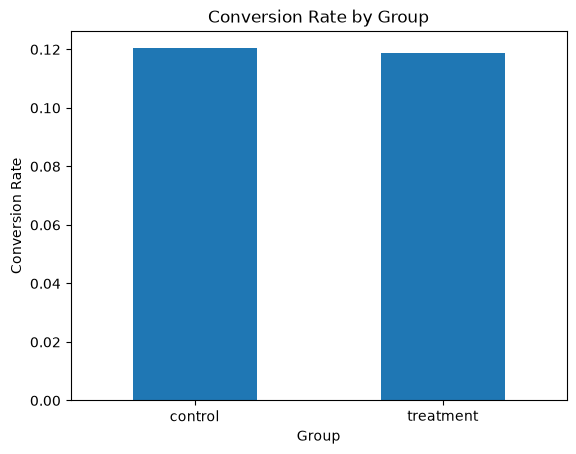

In [3]:
import matplotlib.pyplot as plt

conversion_rates = df.groupby("group")["converted"].mean()

conversion_rates.plot(kind="bar")

plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.show()

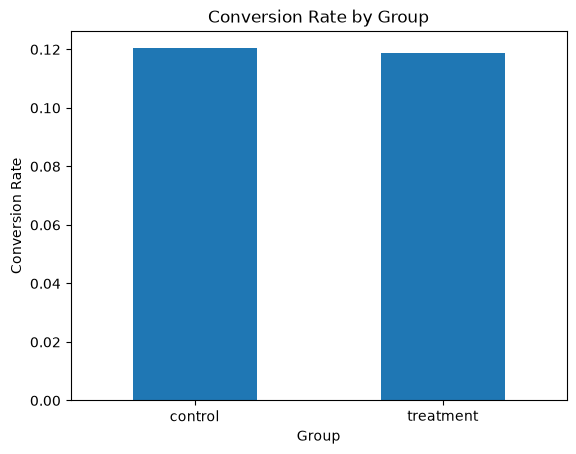

In [4]:
import matplotlib.pyplot as plt

conversion_rates = df.groupby("group")["converted"].mean()

conversion_rates.plot(kind="bar")

plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.show()

In [5]:
print("AB Test Summary")
print()
print("Control conversion rate: 12.03%")
print("Treatment conversion rate: 11.88%")
print("P-value: 0.2269")
print()
print("Conclusion: The p-value is greater than 0.05,")
print("so there is not enough statistical evidence")
print("of a difference in conversion rates between")
print("the control and treatment groups.")

AB Test Summary

Control conversion rate: 12.03%
Treatment conversion rate: 11.88%
P-value: 0.2269

Conclusion: The p-value is greater than 0.05,
so there is not enough statistical evidence
of a difference in conversion rates between
the control and treatment groups.


In [1]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["group"], df["converted"])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
from scipy.stats import chi2_contingency

df = pd.read_csv("ab_data.csv")
df = df.drop_duplicates(subset="user_id", keep="first")

table = pd.crosstab(df["group"], df["converted"])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 1.446408325649827
P-value: 0.22910514252060252
Degrees of freedom: 1


In [ ]:
## Chi-Square Test Result

The Chi-square statistic is 1.46 and the p-value is 0.22.

Since the p-value is greater than 0.05, there is not enough statistical evidence of an association between the experimental group and conversion.

In [3]:
from scipy.stats import ttest_ind

control = df[df["group"] == "control"]["converted"]
treatment = df[df["group"] == "treatment"]["converted"]

t_stat, p_value = ttest_ind(control, treatment, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: 1.2083809283719142
P-value: 0.2269017556231659


In [ ]:
Interpretation: The p-value is 0.2269, which is greater than the significance level of 0.05. Therefore, there is not enough statistical evidence to conclude that the mean conversion differs between the control and treatment groups.